In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
current_year = datetime.now().year
df['Car_Age'] = current_year - df['Year']
df.drop('Year', axis=1, inplace=True)

In [10]:
df['Car_Age'].head()

0    12
1    13
2     9
3    15
4    12
Name: Car_Age, dtype: int64

In [17]:
df = pd.get_dummies(df, columns = ['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)
df.drop('Car_Name', axis=1, inplace=True)

In [18]:
print(df.columns)

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')


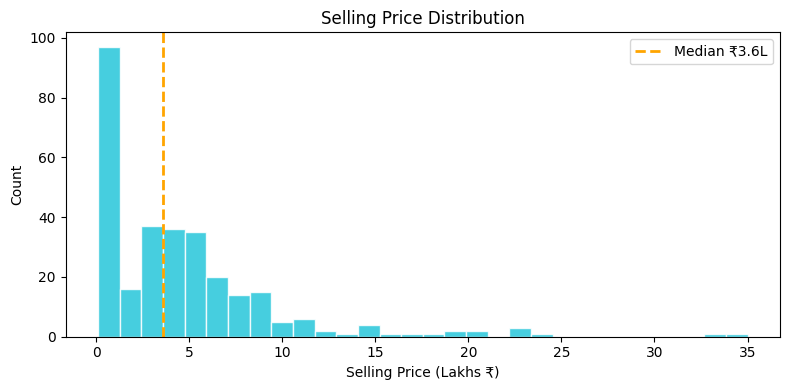

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(df['Selling_Price'], bins=30, color='#26c6da', edgecolor='white', alpha=0.85)
plt.axvline(df['Selling_Price'].median(), color='orange', lw=2, ls='--',
            label=f"Median ₹{df['Selling_Price'].median():.1f}L")
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price (Lakhs ₹)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

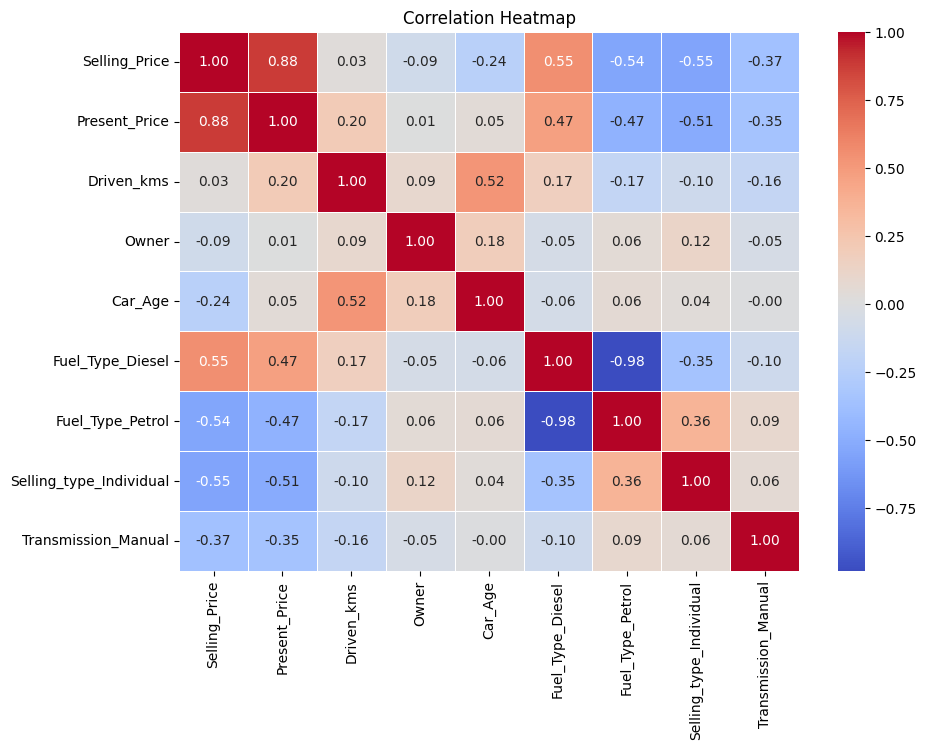

In [21]:
plt.figure(figsize=(10,7))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [23]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
lr = LinearRegression()
lr.fit(X_train , y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

Linear Regression MAE: 1.2163740193330348
Linear Regression MSE: 3.4813498305118147
Linear Regression R²: 0.8488707839193155


In [25]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest MAE: 0.6368655737704919
Random Forest MSE: 0.9339387986885236
Random Forest R²: 0.9594566919773236


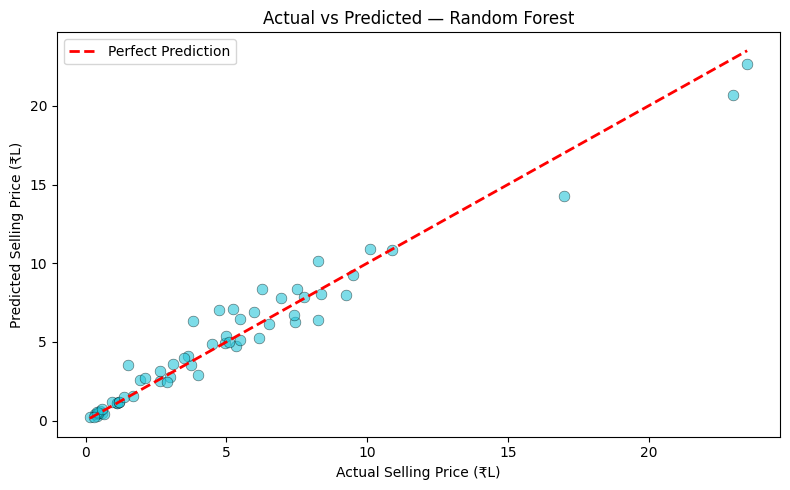

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='#26c6da',
            edgecolors='black', linewidths=0.4, s=60)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Selling Price (₹L)")
plt.ylabel("Predicted Selling Price (₹L)")
plt.title("Actual vs Predicted — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

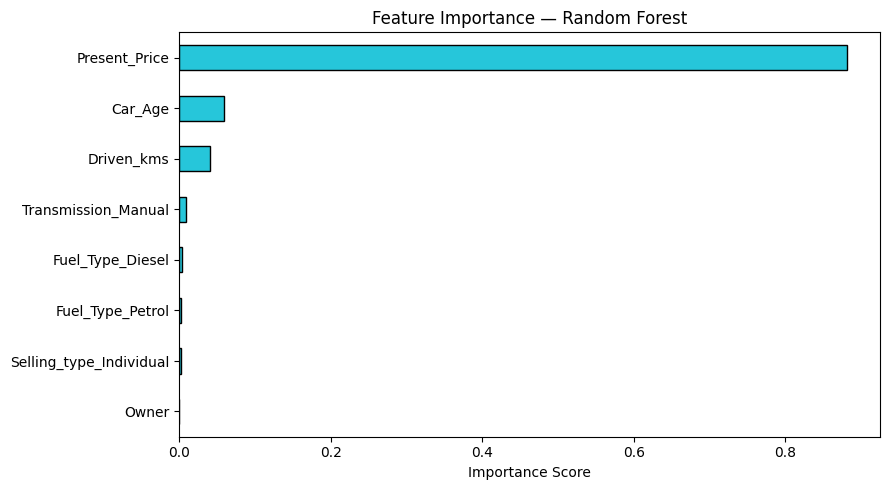

In [27]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='#26c6da', edgecolor='black')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [28]:
print("\nTop Features:")
print(importances.sort_values(ascending=False).to_string())


Top Features:
Present_Price              0.881166
Car_Age                    0.059495
Driven_kms                 0.040265
Transmission_Manual        0.009646
Fuel_Type_Diesel           0.004339
Fuel_Type_Petrol           0.002564
Selling_type_Individual    0.002155
Owner                      0.000370


In [ ]:
sample = pd.DataFrame([{
    'Present_Price'         : 5.59,
    'Driven_kms'            : 27000,
    'Owner'                 : 0,
    'Car_Age'               : 11,
    'Fuel_Type_Diesel'      : 0,
    'Fuel_Type_Petrol'      : 1,   
    'Selling_type_Individual': 0,  
    'Transmission_Manual'   : 1    
}])

predicted = rf.predict(sample)[0]
print(f"\nPredicted Selling Price: ₹ {predicted:.2f} Lakhs")


Predicted Selling Price: ₹ 4.04 Lakhs
